In [1]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, List

class RAGState(TypedDict):
    query:           str
    rewritten_query: str
    docs:            List[str]
    answer:          str

In [2]:
# Node ① Query Rewrite
def rewrite_node(state: RAGState):
    """
    입력: state["query"]
    출력: state["rewritten_query"]
    실제 환경에서는 LLM으로 질문을 정제합니다.
    """
    rewritten = f"{state['query']} (정책 보고서 기준)" # 문자열 추가
    return {"rewritten_query": rewritten}

In [3]:
# Node ② Retrieve
def retrieve_node(state: RAGState):
    """
    입력: state["rewritten_query"]
    출력: state["docs"]
    실제 환경에서는 Vector DB 검색이 수행됩니다.
    """
    docs = [
        "2025년 농업기술 정책 보고서 요약본",
        "2024년 농업 R&D 투자 방향",
        "농업기술 혁신 전략 백서"
    ]
    return {"docs": docs}

In [4]:
# Node ③ Generate
def generate_node(state: RAGState):
    """
    입력: state["docs"]
    출력: state["answer"]
    실제 환경에서는 LLM 호출이 이루어집니다.
    """
    docs   = state["docs"]
    answer = f"총 {len(docs)}개의 문서를 기반으로 2025년 농업기술 정책을 요약했습니다."
    return {"answer": answer}

In [5]:
graph = StateGraph(RAGState)

graph.add_node("rewrite",  rewrite_node)
graph.add_node("retrieve", retrieve_node)
graph.add_node("generate", generate_node)

graph.add_edge(START,      "rewrite")
graph.add_edge("rewrite",  "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)

app = graph.compile()

# 스트림 방식 실행
initial_state = {"query": "2025년 농업기술 관련 정책 보고서를 요약해줘"}
for event in app.stream(initial_state):
    print(event)

{'rewrite': {'rewritten_query': '2025년 농업기술 관련 정책 보고서를 요약해줘 (정책 보고서 기준)'}}
{'retrieve': {'docs': ['2025년 농업기술 정책 보고서 요약본', '2024년 농업 R&D 투자 방향', '농업기술 혁신 전략 백서']}}
{'generate': {'answer': '총 3개의 문서를 기반으로 2025년 농업기술 정책을 요약했습니다.'}}


In [6]:
initial_state = {
    "query": "2025년 농업기술 관련 정책 보고서를 요약해줘"
}

result = app.invoke(initial_state)
print(result["answer"])

총 3개의 문서를 기반으로 2025년 농업기술 정책을 요약했습니다.


In [9]:
def should_compress(state: RAGState) -> str:
    """
    docs 개수가 많으면 Compress Node로 이동
    그렇지 않으면 바로 Generate Node로 이동
    """
    if len(state["docs"]) > 2:
        return "compress"
    return "generate"

In [7]:
def compress_node (state: RAGState):
    """
    입력: state["docs"]
    출력: state["docs"] (압축된 버전)
    문서 수를 줄이거나 요약하는 단계.
    실제 환경에서는 LLM 요약 또는 chunk 축약이 수행됩니다.
    """
    docs            = state["docs"]
    compressed_docs = docs[:2]      # 앞 2개만 사용
    return {"docs": compressed_docs}

In [10]:
from langgraph.graph import StateGraph, END, START

graph = StateGraph(RAGState)

graph.add_node("rewrite",  rewrite_node)
graph.add_node("retrieve", retrieve_node)
graph.add_node("compress", compress_node)
graph.add_node("generate", generate_node)

graph.add_edge(START,     "rewrite")
graph.add_edge("rewrite", "retrieve")

# 조건부 엣지 — retrieve 이후 should_compress 함수로 분기 결정
graph.add_conditional_edges(
    "retrieve",       # 출발 노드
    should_compress,  # 판단 함수
    {
        "compress": "compress",   # "compress" 반환 시 → compress 노드
        "generate": "generate"    # "generate" 반환 시 → generate 노드
    }
)

graph.add_edge("compress", "generate")
graph.add_edge("generate", END)

app = graph.compile()

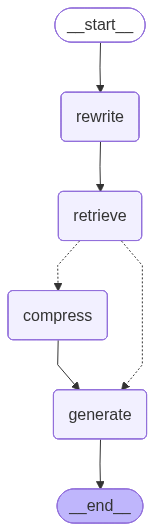

In [12]:
app

In [11]:
initial_state = {"query": "2025년 농업기술 관련 정책 보고서를 요약해줘"}

for event in app.stream(initial_state):
    print(event)

{'rewrite': {'rewritten_query': '2025년 농업기술 관련 정책 보고서를 요약해줘 (정책 보고서 기준)'}}
{'retrieve': {'docs': ['2025년 농업기술 정책 보고서 요약본', '2024년 농업 R&D 투자 방향', '농업기술 혁신 전략 백서']}}
{'compress': {'docs': ['2025년 농업기술 정책 보고서 요약본', '2024년 농업 R&D 투자 방향']}}
{'generate': {'answer': '총 2개의 문서를 기반으로 2025년 농업기술 정책을 요약했습니다.'}}
